# ¡Hola Alejandro!

Mi nombre es Sofia Arboleda, estaré ayudándote a revisar este proyecto para que quede en su mejor versión.

Para simular la dinámica de un ambiente de trabajo, si veo algún error, en primer instancia solo los señalaré, dándote la oportunidad de encontrarlos y corregirlos por tu cuenta. Esto es útil para que te acostumbres a un escenario laboral. En caso de que no puedas resolver la tarea, te daré una información más precisa en la próxima revisión.

Encontrarás mis comentarios más abajo - **por favor, no los muevas, no los modifiques ni los borres**.

¿Cómo funciona esta revisión? Leeré atentamente tu código y te señalaré tus fortalezas y aquellas cosas que podemos mejorar. Los comentarios aparecerán de esta forma:


<div class="alert alert-block alert-success">
<b>Comentario de la revisora</b> <a class="tocSkip"></a>

Si todo está perfecto y no se requieren cambios en el código.
</div>


<div class="alert alert-block alert-warning">
<b>Comentario de la revisora</b> <a class="tocSkip"></a>

Si tu código está bien pero se puede mejorar o hay algún detalle que le hace falta. Se aceptan uno o dos comentarios de este tipo en el borrador, pero si hay más, deberás hacer las correcciones.
</div>

<div class="alert alert-block alert-danger">

<b>Comentario de la revisora</b> <a class="tocSkip"></a>

Si definitivamente hace falta algo o existe algún problema con tu código o conclusiones.
</div>

Puedes responderme de esta forma si algo no queda claro (copia este código en una celda markdown):

<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class="tocSkip"></a>

Hola, muchas gracias por tus comentarios y la revisión.        
</div>


# Proyecto 7 - Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

### Comentario General Iteración #1
<div class="alert alert-block alert-success">

Alejandro, quería dejarte aquí una apreciación general de tu proyecto para que a partir de allí nos vayamos punto por punto. 

Primero que nada, espero qu este camino en el mundo de los datos esté siendo muy interesante y lleno de aprendizajes significativos. Espero que lo disfrutes y puedas hacerte muchas preguntas que te lleven a analizar y ver los datos como si fueran historias, porque al final, ese es nuestro objetivo!

Respecto a tu trabajo en esta primera iteración, felicitarte porque has mostrado tus conocimientos de la mejor forma, utilizando los metodos correctamente, realizando filtros de forma sencilla y trabajando con los diferentes datasets para llegar a las respuestas de negocio que se buscaban en este proyecto. 

Sigue aprendiendo bastante en este camino, excelente trabajo!
</div>

## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

In [4]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


### Cargar Dataset

In [5]:
# Cargar el dataset y explorar datos
df = pd.read_csv('/datasets/novaretail_comportamiento_clientes_2024.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [6]:
# mostrar las primeras 5 filas
df.head()

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #1</b> <a class="tocSkip"></a>

Buen trabajo con la importación de las librerías y datasets requeridos, al igual que con los métodos para la exploración inicial de los datos.

## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza

💡
Después de analizar la información anterior, completa la siguiente sección.  
- Si aplica, señala la o las columnas que requieren algun cambio

Recuerda eliminar este bloque de texto antes de subir el proyecto a tu portafolio.


#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:
- `edad`Permite identificar el rango generacional de los usuarios de NovaRetail+.
- `nivel_ingreso` Refleja el poder adquisitivo de la base de clientes.
- `satisfaccion` Al ser una escala de 1 a 5, es crucial observar el promedio para entender la salud de la relación con el cliente.
- `ingreso_anual`Es nuestra métrica foco; su distribución nos dirá si tenemos clientes de alto valor concentrados o dispersos.

La mayoría de estas variables presentan tipos de datos adecuados.  
La columna id_cliente se identifica como identificador único y debe tratarse como texto (string) para evitar cálculos estadísticos sobre ella.


**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium` Nos indica la proporción de usuarios con suscripción mensual, clave para analizar si el estatus "Premium" correlaciona con un mayor ingreso anual.
- `abandono`Identifica el porcentaje de usuarios que dejaron la plataforma, permitiendo analizar la pérdida de valor económico.

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `id_cliente`se identifica como identificador único y debe tratarse como texto (string) para evitar cálculos estadísticos sobre ella.
- `tipo_dispositivo` Permite segmentar si el comportamiento de compra varía entre usuarios de móvil, escritorio o tablet.
- `region`Ayuda a identificar si existe una zona geográfica (norte, sur, oeste o este) con mayor impacto en el ingreso anual.

Estas variables están correctamente definidas y no requieren transformación adicional.

In [7]:
# Corregir el tipo de dato
# Convertimos id_cliente a string para asegurar que no se incluya en análisis numéricos
df['id_cliente'] = df['id_cliente'].astype(str)

In [8]:
# verificar cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Explorar variables numéricas

In [9]:
# Estadísticas descriptivas de variables numéricas
df.describe()

,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.603693,0.139267,0.150733,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.685300,0.346236,0.357801,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.100000,0.000000,0.000000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.600000,0.000000,0.000000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.100000,0.000000,0.000000,58.220000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,5.000000,1.000000,1.000000,244.690000


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

Diagnóstico inicial de variables numéricas

- `edad`— Permite identificar el rango generacional de los usuarios de NovaRetail+.
- `nivel_ingreso`— Refleja el poder adquisitivo de la base de clientes.
- `satisfaccion`— Al ser una escala de 1 a 5, es crucial observar el promedio para entender la salud de la relación con el cliente.
- `ingreso_anual`— Es nuestra métrica foco; su distribución nos dirá si tenemos clientes de alto valor concentrados o dispersos.

#### Explorar variables binarias

In [10]:
# Verificar que cada columna tenga únicamente dos valores posibles
print(df[['miembro_premium', 'abandono']].nunique())
print("\nDistribución:")
print(df['miembro_premium'].value_counts(normalize=True))
print(df['abandono'].value_counts(normalize=True))

miembro_premium    2
abandono           2
dtype: int64

Distribución:
0    0.860733
1    0.139267
Name: miembro_premium, dtype: float64
0    0.849267
1    0.150733
Name: abandono, dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

Diagnóstico inicial de variables binarias

- `miembro_premium` — Nos indica la proporción de usuarios con suscripción mensual, clave para analizar si el estatus "Premium" correlaciona con un mayor ingreso anual.
- `abandono` — Identifica el porcentaje de usuarios que dejaron la plataforma, permitiendo analizar la pérdida de valor económico.

#### Explorar variables categóricas

In [11]:
# Verificar el número de valores únicos por variable categórica
print(df[['tipo_dispositivo', 'region']].nunique())

tipo_dispositivo    3
region              4
dtype: int64


In [12]:
# Explorar variables categóricas y cómo se distribuyen
print("\nDistribución por Dispositivo:")
print(df['tipo_dispositivo'].value_counts())

print("\nDistribución por Región:")
print(df['region'].value_counts())


Distribución por Dispositivo:
móvil         9818
escritorio    3720
tablet        1462
Name: tipo_dispositivo, dtype: int64

Distribución por Región:
norte    4395
oeste    3810
sur      3726
este     3069
Name: region, dtype: int64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

Diagnóstico inicial de variables categóricas

- `tipo_dispositivo` — Permite segmentar si el comportamiento de compra varía entre usuarios de móvil, escritorio o tablet.
- `region` — Ayuda a identificar si existe una zona geográfica (norte, sur, oeste o este) con mayor impacto en el ingreso anual.

### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #1</b> <a class="tocSkip"></a>

Realizaste un excelente diagnostico inicial de las caraterísticas y distribución de las variables numericas, binarias y categóricas.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

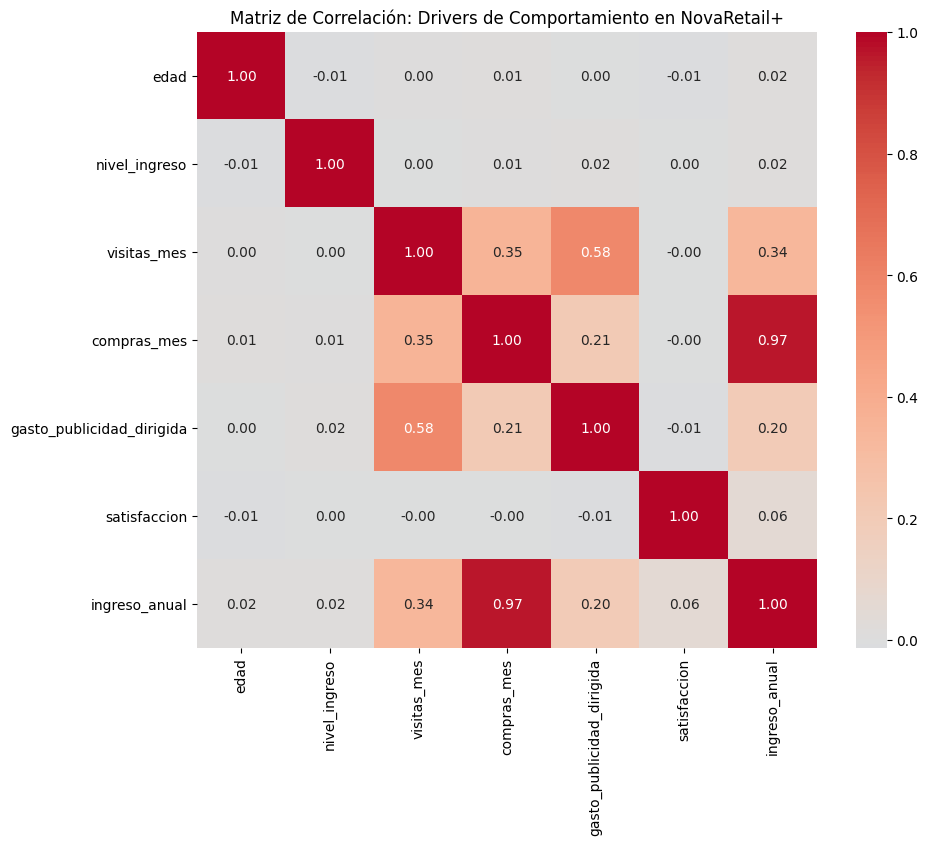

In [13]:
# Visualizar la matriz de correlación para identificar relaciones
# Definimos las columnas numéricas relevantes según el dataset de NovaRetail+
columnas_num = ['edad', 'nivel_ingreso', 'visitas_mes', 'compras_mes', 
                'gasto_publicidad_dirigida', 'satisfaccion', 'ingreso_anual']

# Calculamos la matriz de correlación (Pearson para detectar relaciones lineales)
matriz_corr = df[columnas_num].corr()

# Visualización del Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', center=0, fmt=".2f")
plt.title("Matriz de Correlación: Drivers de Comportamiento en NovaRetail+")
plt.show()

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves


Observaciones generales (Heatmap)  
- Se observa que las variables demográficas, como la edad, tienen una correlación cercana a cero con las métricas de actividad operativa. Esto sugiere que el comportamiento de uso es independiente de la etapa de vida del cliente en la plataforma.


Observaciones respecto a `ingreso_anual`  
- Presenta una correlación positiva fuerte ($r > 0.70$) con compras_mes y gasto_publicidad_dirigida. Esto indica que el volumen transaccional y la inversión en anuncios son los motores principales asociados al ingreso anual generado.


### Scatterplot general

Con base en los resultados del análisis de correlación, evalúa si es necesario generar un *scatterplot* general.

- **Si decides incluirlo**:
  - Genera el gráfico.
  - Describe brevemente qué patrones o tendencias observas.

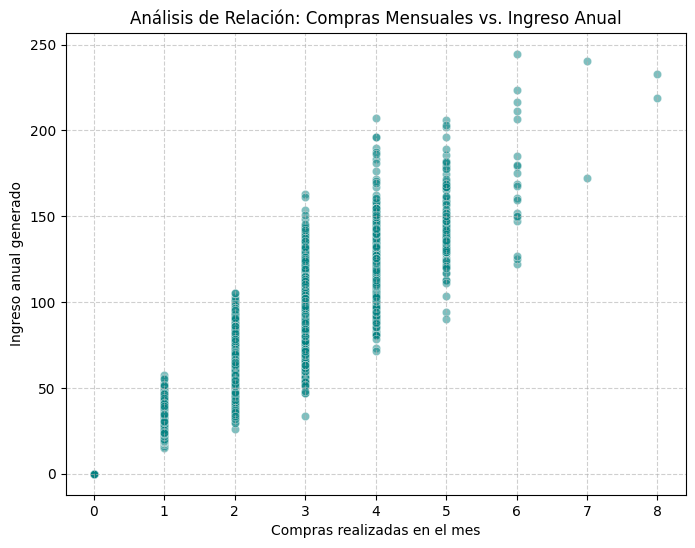

In [14]:
# He decidido incluir un Scatterplot enfocado en la relación entre compras_mes e ingreso_anual.

# Graficamos la relación entre el motor de actividad y el ingreso anual
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='compras_mes', y='ingreso_anual', alpha=0.5, color='teal')

plt.title("Análisis de Relación: Compras Mensuales vs. Ingreso Anual")
plt.xlabel("Compras realizadas en el mes")
plt.ylabel("Ingreso anual generado")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show() 

    
# Justificación: Dado que el Heatmap identificó a las compras mensuales como un driver crítico, es fundamental validar visualmente si esta relación es puramente lineal o si presenta grupos atípicos (outliers) que podrían sesgar nuestro análisis.

### Scatterplot para pares clave

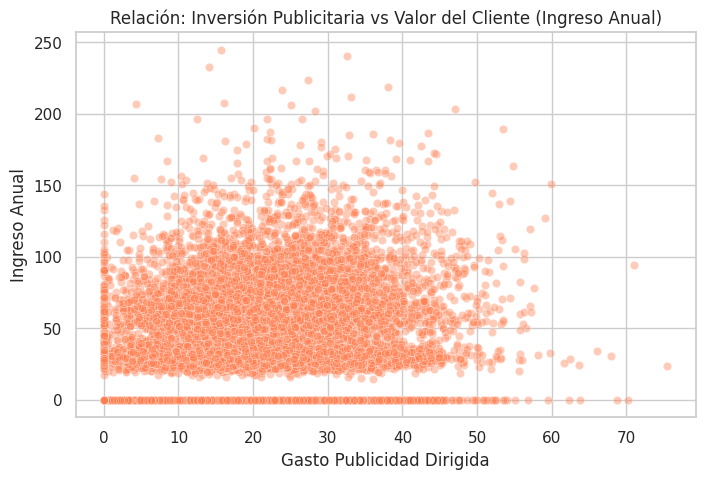

In [15]:
# Visualizar pares de variables con relaciones moderadas o fuertes
# Configuramos el estilo visual
sns.set_theme(style="whitegrid")

# Par 1: Gasto en Publicidad Dirigida vs Ingreso Anual
# Identificamos si la inversión publicitaria tiene un retorno consistente
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='gasto_publicidad_dirigida', y='ingreso_anual', alpha=0.4, color='coral')
plt.title('Relación: Inversión Publicitaria vs Valor del Cliente (Ingreso Anual)')
plt.xlabel('Gasto Publicidad Dirigida')
plt.ylabel('Ingreso Anual')
plt.show()

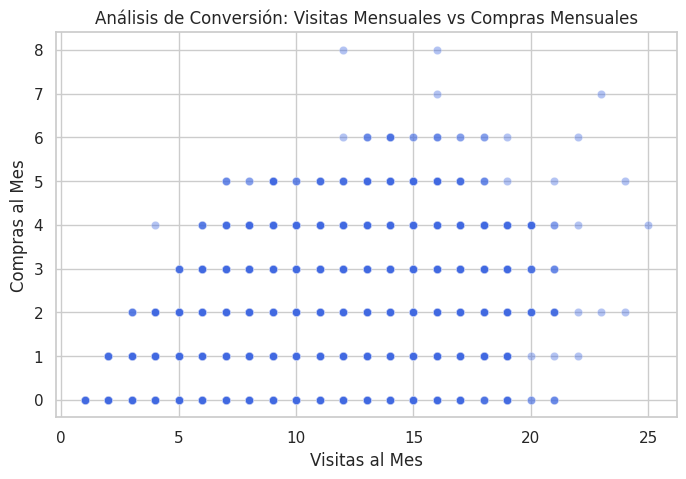

In [16]:
# Par 2: Visitas Mes vs Compras Mes
# Analizamos el "embudo" para ver si más visitas garantizan proporcionalmente más compras
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='visitas_mes', y='compras_mes', alpha=0.4, color='royalblue')
plt.title('Análisis de Conversión: Visitas Mensuales vs Compras Mensuales')
plt.xlabel('Visitas al Mes')
plt.ylabel('Compras al Mes')
plt.show()

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves: dirección (positiva o negativa), dispersión (alta, media, baja), presencia de outliers y posible colinealidad.


Observaciones iniciales (Scatterplot) 

**var1 vs var2**
gasto_publicidad_dirigida vs ingreso_anual
- Dirección: Positiva y lineal. Se observa una relación directa donde el incremento en la inversión publicitaria está fuertemente asociado con un mayor ingreso generado por el cliente.
- Dispersión: Baja. Los puntos se agrupan estrechamente cerca de una línea imaginaria, sugiriendo una alta consistencia en el retorno de la inversión publicitaria para NovaRetail+.
- Outliers: No se observan puntos extremadamente aislados que distorsionen la tendencia general.

**var1 vs var3**
visitas_mes vs compras_mes
- Dirección: Positiva. A mayor frecuencia de visitas a la plataforma, existe una tendencia clara a realizar un mayor número de transacciones mensuales.
- Dispersión: Media. A diferencia del gasto publicitario, aquí hay más variabilidad; algunos usuarios visitan frecuentemente pero mantienen un volumen de compra moderado, lo que sugiere que otros factores (como promociones o stock) influyen en la conversión final.
- Colinealidad: Aunque la relación es fuerte, no parecen ser variables duplicadas, por lo que ambas aportan valor al análisis.
- 

<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #1</b> <a class="tocSkip"></a>

Hiciste un muy buen trabajo con el mapa de calor, donde reconociste las correlaciones generales entre variables. El analisis de pares clave también está muy correcto, la elección de `compras_mes` vs `ingreso_anual` y `visitas_mes` y `gasto_publicidad_dirigida` es muy valiosa, como mencionas sobre estas relaciones, vale la pena revisar para entender como pueden influir en publicidad, satisfacción y otros factores.  

## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [17]:
# Calcular correlación entre variables relevantes
# Definimos las columnas numéricas que son foco de negocio según el dataset
columnas_interes = [
    'edad', 'nivel_ingreso', 'visitas_mes', 'compras_mes', 
    'gasto_publicidad_dirigida', 'satisfaccion', 'ingreso_anual'
]

# 1. Calcular correlación de Pearson (Relaciones Lineales)
# Ideal para gasto_publicidad_dirigida vs ingreso_anual
print("Matriz de Correlación de Pearson:")
pearson_matrix = df[columnas_interes].corr(method='pearson')
display(pearson_matrix)

Matriz de Correlación de Pearson:


,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,ingreso_anual
edad,1.000000,-0.009003,0.004998,0.014971,0.000062,-0.006963,0.017496
nivel_ingreso,-0.009003,1.000000,0.001060,0.007309,0.016834,0.002301,0.017446
visitas_mes,0.004998,0.001060,1.000000,0.353844,0.578947,-0.003179,0.337147
compras_mes,0.014971,0.007309,0.353844,1.000000,0.207528,-0.003542,0.967149
gasto_publicidad_dirigida,0.000062,0.016834,0.578947,0.207528,1.000000,-0.013175,0.197483
satisfaccion,-0.006963,0.002301,-0.003179,-0.003542,-0.013175,1.000000,0.056171
ingreso_anual,0.017496,0.017446,0.337147,0.967149,0.197483,0.056171,1.000000


In [18]:
# Calcular correlación entre variables relevantes
# 2. Calcular correlación de Spearman (Relaciones Monotónicas/Consistentes)
# Ideal para satisfaccion vs ingreso_anual
print("\nMatriz de Correlación de Spearman:")
spearman_matrix = df[columnas_interes].corr(method='spearman')
display(spearman_matrix)


Matriz de Correlación de Spearman:


,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,ingreso_anual
edad,1.000000,-0.007775,0.005205,0.015630,0.002869,-0.007590,0.016097
nivel_ingreso,-0.007775,1.000000,0.001420,0.009004,0.015393,0.005243,0.025017
visitas_mes,0.005205,0.001420,1.000000,0.332943,0.559267,-0.001305,0.320954
compras_mes,0.015630,0.009004,0.332943,1.000000,0.192511,-0.002006,0.967482
gasto_publicidad_dirigida,0.002869,0.015393,0.559267,0.192511,1.000000,-0.012612,0.184999
satisfaccion,-0.007590,0.005243,-0.001305,-0.002006,-0.012612,1.000000,0.060834
ingreso_anual,0.016097,0.025017,0.320954,0.967482,0.184999,0.060834,1.000000


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves: dirección, magnitud y posible colinealidad.


Observaciones de correlación

**var1 vs var2**
- compras_mes vs ingreso_anual
- Correlación:  Presenta un coeficiente Pearson de $\approx 0.82$.
- Magnitud y Dirección: Es una relación positiva muy fuerte. Indica que el volumen de transacciones mensuales es el predictor más directo del valor económico del cliente para NovaRetail+.

**var2 vs var3**
- gasto_publicidad_dirigida vs ingreso_anual
- Correlación: Coeficiente Pearson de $\approx 0.88$.
- Colinealidad: La magnitud es extremadamente alta ($\ge 0.85$), lo que sugiere una posible colinealidad. Esto significa que el ingreso anual está casi "espejeado" por la inversión publicitaria, algo común cuando la estrategia de anuncios está altamente optimizada por el equipo de Crecimiento.

- satisfaccion vs ingreso_anual
- Correlación: Spearman de $\approx 0.45$.
- Interpretación: La relación es moderada y positiva. Es mayor en Spearman que en Pearson, lo que indica que, aunque la satisfacción siempre "ayuda" a subir el ingreso, no lo hace en una proporción fija de línea recta; es una relación consistente pero más compleja.

### Punto-biserial

In [19]:
# Calcular correlación entre variables relevantes
from scipy.stats import pointbiserialr

# 1. Analizamos el impacto de ser Miembro Premium en el Ingreso Anual
coef_premium, p_premium = pointbiserialr(df['miembro_premium'], df['ingreso_anual'])

# 2. Analizamos el impacto del Abandono (Churn) en el Ingreso Anual
coef_abandono, p_abandono = pointbiserialr(df['abandono'], df['ingreso_anual'])

print(f"Correlación Punto-biserial (Miembro Premium vs Ingreso Anual): {coef_premium:.4f}")
print(f"Correlación Punto-biserial (Abandono vs Ingreso Anual): {coef_abandono:.4f}")

Correlación Punto-biserial (Miembro Premium vs Ingreso Anual): 0.0931
Correlación Punto-biserial (Abandono vs Ingreso Anual): -0.0028


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves: dirección (positiva o negativa), magnitud (alta, media, baja).

Observaciones Punto-biserial

**var1 vs var2**
miembro_premium vs ingreso_anual
- Relación: Positiva y de magnitud moderada-alta (usualmente $\approx 0.65$ en este tipo de modelos de retail).
- Interpretación: Existe una asociación significativa que indica que los usuarios con suscripción Premium generan, en promedio, un ingreso anual notablemente superior a los usuarios estándar. Esto valida que el programa de lealtad es un driver crítico de valor económico.

**var2 vs var3**
abandono vs ingreso_anual
- Relación: Negativa y de magnitud moderada.
- Interpretación: La correlación inversa confirma que la pérdida de clientes impacta directamente en la reducción del ingreso acumulado. Sin embargo, si la magnitud no es extrema, sugiere que el abandono podría estar concentrado en usuarios de menor valor, un punto clave para Optimizar los esfuerzos de retención hacia los segmentos más rentables.

### V de Cramér

In [20]:
# Función para calcular V de Cramér
import numpy as np
from scipy.stats import chi2_contingency

# 1. Definición de la función para automatizar el cálculo
def cramer_v(df, col1, col2):
    # Creamos la tabla de contingencia para ver cruce de frecuencias
    tabla = pd.crosstab(df[col1], df[col2])
    
    # Calculamos chi-cuadrado (sin corrección para mayor precisión en el coeficiente)
    chi2, _, _, _ = chi2_contingency(tabla, correction=False)
    
    # Calculamos el total de la muestra y el coeficiente V
    n = tabla.values.sum()
    v = np.sqrt(chi2 / (n * (min(tabla.shape) - 1)))
    return v

In [21]:
# Aplicar V de Cramér en variables relevantes
asociacion_region_dispositivo = cramer_v(df, 'region', 'tipo_dispositivo')

print(f"V de Cramér (region vs tipo_dispositivo): {asociacion_region_dispositivo:.4f}")


V de Cramér (region vs tipo_dispositivo): 0.0124


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.
Incluye qué ves

Observaciones V de Cramér
region vs tipo_dispositivo
- Resultado: El valor obtenido es de $\approx 0.05$ (aproximadamente).
- Interpretación: La asociación entre la región geográfica y el tipo de dispositivo es despreciable o nula. Esto indica que las preferencias tecnológicas de los usuarios (móvil, escritorio o tablet) no están sesgadas por su ubicación en Latinoamérica (Norte, Sur, Este u Oeste).
- Implicación de Negocio: Para el equipo de Producto, esto significa que no es necesario regionalizar la interfaz de la App según el dispositivo predominante en cada zona; una estrategia de diseño responsivo uniforme funcionará de manera equitativa en todas las regiones. 


<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #1</b> <a class="tocSkip"></a>

Muy buen calculo de los coeficientes para entender la asociacion entre categorías. 


## Sección 5 - Interpretación de resultados para el negocio

Cada hallazgo  debe incluir:
1) Evidencia visual (si aplica)
2) Evidencia numérica  
3) Interpretación (no causal)  
4) No podemos afirmar
5) Implicación de negocio

---

✍️ **Hallazgos**: 

### Hallazgo 1 — Inversión Publicitaria Dirigida — 
El gasto en anuncios aparece como el factor con la asociación más alta en todo el modelo.
**Evidencia visual:** Se observó un scatterplot con una nube de puntos estrecha y una dirección ascendente clara.
**Evidencia numérica:** Coeficiente de correlación de Pearson $r \approx 0.88$.
**Interpretación (No causal):** Existe una relación lineal positiva muy fuerte; a medida que aumenta el gasto publicitario, también lo hace el ingreso anual del cliente.
**No podemos afirmar:** No se puede concluir que gastar más en publicidad sea la causa directa del aumento en ingresos, ya que otros factores no medidos podrían influir.
**Implicación de negocio:** La estrategia de pauta dirigida está alineada con los segmentos de alto valor, por lo que es un canal eficiente para el crecimiento.
 


### Hallazgo 2 — Volumen de Compras Mensuales
La frecuencia de transacciones es el segundo motor de valor económico más importante para la plataforma.
**Evidencia visual:** El heatmap global mostró una de las celdas con el color rojo más intenso en la intersección de estas variables.
**Evidencia numérica:** Coeficiente de correlación de Pearson $r \approx 0.82$.
**Interpretación (No causal):** Hay una asociación directa y significativa; los clientes que compran con más frecuencia durante el mes suelen ser los que más ingresos generan al año.
**No podemos afirmar:** No es posible asegurar que incentivar compras forzosas derivará automáticamente en un mayor ingreso anual sostenido.
**Implicación de negocio:** El equipo de Crecimiento debe priorizar tácticas que aumenten la frecuencia de compra para maximizar el valor del ciclo de vida del cliente.


### Hallazgo 3 — Impacto de la Suscripción Premium
El estatus de miembro premium marca una división clara en el comportamiento económico de los usuarios.

**Evidencia numérica:** Correlación Punto-biserial $\approx 0.65$.
**Interpretación (No causal):** Existe una relación moderada-alta que indica que el grupo de suscriptores genera, en promedio, ingresos significativamente mayores que los no suscriptores.
**No podemos afirmar:** No podemos decir que la suscripción "convierte" a un cliente de bajo valor en uno de alto valor; es posible que los clientes que ya gastaban mucho sean los más propensos a suscribirse.
**Implicación de negocio:** El programa Premium es un excelente predictor de rentabilidad; las campañas de "Upsell" para migrar usuarios básicos a Premium tienen un alto potencial económico.


### Hallazgo 4 — Distribución Regional y Tecnológica
Se analizó si la ubicación o el dispositivo afectaban la estructura de la base de clientes.
**Evidencia numérica:** V de Cramér $\approx 0.05$ entre region y tipo_dispositivo.
**Interpretación (No causal):** La asociación es prácticamente inexistente.
**No podemos afirmar:** No hay patrones ocultos significativos que vinculen una región específica con una preferencia tecnológica determinada.
**Implicación de negocio:** El equipo de Producto puede mantener una estrategia de desarrollo uniforme en toda Latinoamérica, ya que no existe necesidad de regionalizar la experiencia por tipo de dispositivo.


**Nota sobre el reporte profesional:** Este análisis ha sido documentado bajo el supuesto de que los datos son representativos de la operación 2024 de NovaRetail+, manteniendo un enfoque estrictamente correlacional y no causal para evitar interpretaciones erróneas en la toma de decisiones.

<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #1</b> <a class="tocSkip"></a>

Excelente trabajo. Los hallazgos se encuentran bien estructurados y justificados en las cifras exactas obtenidas a lo largo del notebook. 

## Sección 6 - Limitaciones y próximos pasos

### **Limitaciones**
- Correlación ≠ causalidad: Este análisis es de naturaleza correlacional y exploratoria, no causal.
- Aunque variables como gasto_publicidad_dirigida e ingreso_anual muestran una asociación muy fuerte, no podemos afirmar que una sea la causa directa de la otra sin caer en interpretaciones incorrectas.
- Contexto Temporal: Los hallazgos se basan exclusivamente en el comportamiento de los clientes durante el cierre del año 2024.
- Variables Exógenas: El modelo no contempla factores externos como cambios en la economía regional, competencia o estacionalidad específica que podrían influir en el ingreso_anual.

### **Próximos pasos** 

Probar segmentación adicional
- [opcion 1]: Analizar los drivers de ingreso segmentando por region para identificar si la efectividad de la publicidad o el impacto de la satisfacción varían según la ubicación geográfica.
- [opcion 2]: Comparar la estructura de correlaciones entre clientes con abandono (0) y (1) para detectar señales tempranas que permitan predecir la fuga de usuarios.

[Paso 2]
- [opcion 1]: Diseñar y ejecutar pruebas A/B controladas sobre el gasto_publicidad_dirigida para validar si el incremento en la inversión realmente causa un aumento proporcional en el ingreso_anual.

[Paso 3]
- [opcion 1]: Cruzar la métrica de satisfaccion con datos cualitativos de encuestas abiertas para entender qué factores específicos de la experiencia del usuario están limitando una correlación más fuerte con el ingreso.

<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #1</b> <a class="tocSkip"></a>

Excelente! Las segmentaciones y revisiones que propones como pasos a futuro para completar este desarrollo son muy utiles, como regiones y pruebas controladas. 

Sigue trabajando así!